# Data Processing and Bipartite Graph

We use the MOOC User Action Dataset from  the Stanford's SNAP library.  The nodes represent users to course activities (targets), and edges represent the actions by users on the targets.

**The dataset consists of:**
- Number of users	7,047
- Number of targets	97
- Number of actions	411,749

**Source:** https://snap.stanford.edu/data/act-mooc.html

<br>

**Data Processing**
- We ingest the mooc action data to construct an undirected bipartite graph of users and targets.
- We systematically remove the three highest-degree target hubs and filters out users with fewer than three interactions.
- Produces a sparse biadjacency matrix representing the refined network structure.
- We reduce structural noise in the  the two-mode graph for projection into single-mode networks by removing "universal" connections.
- Prevent density inflation by eliminating massive hubs to remove artificial "clique" effect during projection which create superficial links between nearly all users.
- Filter peripheral noise to ensure analysis is grounded in established interaction patterns.

<br>

**Results & Interpretation**
- We condensed the network to a core of 6,460 users and 94 targets.
- Removing only three hubs and low-activity users shed over 19,000 superficial edges, proving that a tiny fraction of nodes disproportionately inflates network density.
- This significant reduction is necessary sparsification to uncover meaningful community structures.


In [1]:
# Imports libraries
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite
import scipy.sparse as sp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import networkx.algorithms.community as nx_comm
from google.colab import files

# Load dataset from repo
url = 'https://raw.githubusercontent.com/johnnydrodriguez/data620/refs/heads/main/mooc_actions.tsv'
df_actions = pd.read_csv(url, sep='\t')

# Cleans up user and target node identifiers.
df_actions['user_node'] = 'U_' + df_actions['USERID'].astype(str)
df_actions['target_node'] = 'T_' + df_actions['TARGETID'].astype(str)

# Initializes an undirected bipartite graph.
G = nx.Graph()

# Adds nodes with the required bipartite attribute.
G.add_nodes_from(df_actions['user_node'].unique(), bipartite=0)
G.add_nodes_from(df_actions['target_node'].unique(), bipartite=1)

# Adds edges to the graph.
G.add_edges_from(zip(df_actions['user_node'], df_actions['target_node']))

# Identifies user and target node sets.
users = {n for n, d in G.nodes(data=True) if d.get("bipartite") == 0}
targets = set(G) - users

# Outputs the initial dimensions of the unpruned network.
print(f"Original Bipartite Graph: {len(users)} Users, {len(targets)} Targets, {G.number_of_edges()} Edges.")

# Calculates target degrees to identify hubs.
target_degrees = sorted([(t, G.degree(t)) for t in targets], key=lambda x: x[1], reverse=True)

# Removes the highest degree target hubs.
hubs_to_remove = [t for t, degree in target_degrees[:3]]
G.remove_nodes_from(hubs_to_remove)

# Identifies users with minimal interactions.
users_to_remove = [u for u in users if G.has_node(u) and G.degree(u) < 3]

# Removes low-engagement users.
G.remove_nodes_from(users_to_remove)

# Updates node lists after pruning.
users = [n for n, d in G.nodes(data=True) if d.get("bipartite") == 0]
targets = [n for n, d in G.nodes(data=True) if d.get("bipartite") == 1]

# Generates the sparse biadjacency matrix.
B = bipartite.biadjacency_matrix(G, row_order=users, column_order=targets)

# Outputs the resulting dimensions of the pruned network.
print(f"Pruned Bipartite Graph: {len(users)} Users, {len(targets)} Targets, {G.number_of_edges()} Edges.")

Original Bipartite Graph: 7047 Users, 97 Targets, 178443 Edges.
Pruned Bipartite Graph: 6460 Users, 94 Targets, 159025 Edges.


# Network Backbone Extraction and Sparsification Using Disparity Filter

**Data Processing**
- We sparsify the network backbone to isolate significant edges and refine the initial projection.
- We break up the highly dense network to prevent the Louvain communty detection algorithm from grouping all users into a single, indistinguishable mass.
- The disparity filter extracts the structural backbone of the network by by evaluating the significance of each edge's weight relative to the total strength of its connected nodes. Its preserves the network's integrity by filtering out noise without disproportionately isolating lower-degree nodes.

<br>

**Results & Interpretation**
- We reduced the network to a backbone of 872 distinct users and 35,150 significant edges using the Louvain algorithm.
- This significant reduction ensures the topology is optimized for identifying distinct community structures rather than a universal cluster.


In [2]:
# Computes the unipartite projection matrix
proj_matrix = B.dot(B.T)

# Removes self-loops
proj_matrix.setdiag(0)
proj_matrix.eliminate_zeros()

# Converts the matrix to coordinate (COO) format
proj_coo = proj_matrix.tocoo()

# Extracts row indices, column indices, and edge weights.
row_indices = proj_coo.row
col_indices = proj_coo.col
edge_weights = proj_coo.data

# Calculates degree (k) and strength (s) for all nodes
node_degrees = np.bincount(row_indices, minlength=proj_matrix.shape[0])
node_strengths = np.bincount(row_indices, weights=edge_weights, minlength=proj_matrix.shape[0])

# Maps the degree and strength
source_degrees = node_degrees[row_indices]
source_strengths = node_strengths[row_indices]

# Calculates normalized edge weights
normalized_weights = edge_weights / source_strengths

# Restricts normalized weights to [0, 1]
normalized_weights = np.clip(normalized_weights, 0, 1)

# Calculates the null model probability (p-value) for the disparity filter.
p_values = (1 - normalized_weights) ** np.maximum((source_degrees - 1), 1)

# Sets the statistical significance threshold (alpha).
significance_level = 0.05

# Creates a boolean mask identifying edges that are statistically significant.
significant_mask = p_values < significance_level

# Filters the coordinate arrays using the boolean mask.
filtered_rows = row_indices[significant_mask]
filtered_cols = col_indices[significant_mask]
filtered_weights = edge_weights[significant_mask]

# Builds a new sparse matrix containing only the significant "backbone" edges.
backbone_matrix = sp.coo_matrix(
    (filtered_weights, (filtered_rows, filtered_cols)),
    shape=proj_matrix.shape
)
backbone_matrix.eliminate_zeros()

# Constructs the final backbone graph
backbone_graph = nx.from_scipy_sparse_array(backbone_matrix)

# Maps integer indices back to users
node_mapping = {idx: user for idx, user in enumerate(users)}
backbone_graph = nx.relabel_nodes(backbone_graph, node_mapping)

# Removes solated nodes from the graph.
backbone_graph.remove_nodes_from(list(nx.isolates(backbone_graph)))

print(f"Final Backbone Graph: {backbone_graph.number_of_nodes()} Nodes, {backbone_graph.number_of_edges()} Edges")

Final Backbone Graph: 872 Nodes, 35150 Edges


# Community Detection and Cohort Segmentation

**Data Processing**
- We apply the Louvain modularity optimization algorithm to the sparsified backbone graph to detect discrete cohorts.
- We calculate internal topological metrics for each resulting community, including total node count and internal edge density.
- We format community assignments as node attributes and export the structured data into a Gephi GEXF file for visual analysis.  The user-to-user network is too computationally intensive to model in the Google Colab notebook.

<br>

**Results & Interpretation**
- We partitioned the network into four distinct cohorts.  Given this dataset, the cohorts likely map onto distinct academic tracks, departments, or learning programs of the mooc.
- Communities 4 and 2 form the dense, highly engaged core, representing users who follow exhaustive and nearly identical learning trajectories.
- Communities 1 and 3 populate the network periphery, likely representing selective learners and casual browsers with connections through introductory modules.

In [3]:
# Executes Louvain community detection on the backbone graph.
communities_U = nx_comm.louvain_communities(backbone_graph, weight='weight', seed=42)
print(f"Algorithm identified {len(communities_U)} distinct user communities.\n")

# Initializes a list to store community metrics.
community_metrics = []

# Iterates through communities to calculate topological metrics.
for idx, comm in enumerate(communities_U):
    # Extracts the subgraph for the specific community.
    subgraph = backbone_graph.subgraph(comm)

    # Calculates node and edge counts.
    num_nodes = subgraph.number_of_nodes()
    num_edges = subgraph.number_of_edges()

    # Computes internal density
    if num_nodes > 1:
        max_internal_edges = (num_nodes * (num_nodes - 1)) / 2
        internal_density = num_edges / max_internal_edges
    else:
        internal_density = 0

    # Appends calculated metrics to the list.
    community_metrics.append({
        'Community_ID': idx + 1,
        'User_Count': num_nodes,
        'Internal_Edges': num_edges,
        'Internal_Density': round(internal_density, 4)
    })

# Converts metrics to a sorted dataframe
df_communities = pd.DataFrame(community_metrics).sort_values(by='User_Count', ascending=False).reset_index(drop=True)

# Outputs the community distribution summary.
print("Community Distribution Summary:")
print(df_communities.to_string())
print("\n")

# Iterates through communities to assign attributes to the graph.
for idx, comm in enumerate(communities_U):
    for node in comm:
        backbone_graph.nodes[node]['community'] = idx + 1

# Ensures community identifiers are standard integers
for node, data in backbone_graph.nodes(data=True):
    if 'community' in data:
        data['community'] = int(data['community'])

# Ensures edge weights are standard floats
for u, v, data in backbone_graph.edges(data=True):
    if 'weight' in data:
        data['weight'] = float(data['weight'])

# Defines the output filename.
output_filename = "user_backbone_network.gexf"

# Writes the graph to a file for visualization.
nx.write_gexf(backbone_graph, output_filename)

print("Initiating Gephi file download.")

#  file download.
files.download(output_filename)

Algorithm identified 4 distinct user communities.

Community Distribution Summary:
   Community_ID  User_Count  Internal_Edges  Internal_Density
0             3         377            2627            0.0371
1             4         199           10111            0.5132
2             2         196            7803            0.4083
3             1         100             413            0.0834


Initiating Gephi file download.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
from IPython.display import Image

# Display the image from the GitHub URL
url = 'https://raw.githubusercontent.com/johnnydrodriguez/data620/main/user_mooc_affiliation_network.png'
Image(url=url)

#  Action-to-Action Topology Projection

**Data Processing**
- We generate the single-mode Action-to-Action projection by multiplying the transposed biadjacency matrix by itself
- We apply a strict 95th percentile global threshold to isolate only the most frequent target co-occurrences.
- We execute the Louvain algorithm to map course modules and calculate betweenness centrality for all nodes. Isolate dominant learning pathways by filtering out sparsely connected or optional materials

<br>

**Results & Interpretation**
- We distilled the 94-target syllabus into a structural backbone of 31 core activities.
- The community detection algorithm grouped these activities into three sequential learning phases, each anchored by a primary hub.
- Target 28 emerged as a critical gateway and the highest-traffic bridge, indicating it is a mandatory transition point between distinct curriculum phases.


In [5]:
# Computes the action projection matrix.
P_A = B.T.dot(B)

# Removes self-loops from the matrix.
P_A.setdiag(0)

# Converts the dense matrix to a dataframe.
df_actions_net = pd.DataFrame(P_A.toarray(), index=targets, columns=targets)

# Extracts edge weights from the upper triangle.
matrix_values = df_actions_net.values
upper_tri_indices = np.triu_indices_from(matrix_values, k=1)
edge_weights = matrix_values[upper_tri_indices]

# Calculates the global threshold using the target percentile.
tau_A = int(np.percentile(edge_weights, 95))
print(f"Global Threshold (95th Percentile): Retaining edges with weight >= {tau_A}")

# Initializes the action graph.
G_actions = nx.Graph()

# Iterates through the matrix to add edges meeting the threshold.
targets_list = df_actions_net.index.tolist()
for idx in range(len(targets_list)):
    for jdx in range(idx + 1, len(targets_list)):
        weight = matrix_values[idx, jdx]
        if weight >= tau_A:
            G_actions.add_edge(targets_list[idx], targets_list[jdx], weight=weight)

print(f"Sparsified Action Graph: {G_actions.number_of_nodes()} Nodes, {G_actions.number_of_edges()} Edges\n")

# Executes Louvain community detection with a fixed seed.
communities_A = nx_comm.louvain_communities(G_actions, weight='weight', seed=42)
print(f"Louvain algorithm identified {len(communities_A)} distinct action communities.\n")

# Calculates betweenness centrality
betweenness_A = nx.betweenness_centrality(G_actions, weight='weight')

# Initializes a list to store module metrics.
module_metrics = []

# Iterates through communities to identify primary hubs and module sizes.
for idx, comm in enumerate(communities_A):
    subgraph = G_actions.subgraph(comm)
    degrees = dict(subgraph.degree())
    primary_hub = max(degrees, key=degrees.get)

    module_metrics.append({
        'Module_ID': idx + 1,
        'Action_Count': len(comm),
        'Internal_Edges': subgraph.number_of_edges(),
        'Primary_Hub_Action': primary_hub
    })

# Converts metrics to a sorted dataframe
df_modules = pd.DataFrame(module_metrics).sort_values(by='Action_Count', ascending=False)
print("Action Communities (Course Modules) Summary:")
print(df_modules.to_string(index=False))
print("\n")

# Sorts gateway actions by centrality score.
sorted_betweenness = sorted(betweenness_A.items(), key=lambda x: x[1], reverse=True)

# Outputs the top structural bottlenecks.
print("Top 3 'Gateway' Actions (Highest Betweenness Centrality):")
for target, bc in sorted_betweenness[:3]:
    print(f"{target}: {bc:.4f}")

Global Threshold (95th Percentile): Retaining edges with weight >= 2163
Sparsified Action Graph: 31 Nodes, 220 Edges

Louvain algorithm identified 3 distinct action communities.

Action Communities (Course Modules) Summary:
 Module_ID  Action_Count  Internal_Edges Primary_Hub_Action
         1            12              53                T_8
         2            10              31                T_7
         3             9              20               T_28


Top 3 'Gateway' Actions (Highest Betweenness Centrality):
T_28: 0.1057
T_26: 0.0897
T_32: 0.0851


# Visualization for Action-to-Action Clusters (Modules)

**Data Processing**
- We construct a static, dual-encoded network visualization of the sparsified action topology.
- We map Louvain community assignments to discrete categorical colors and scale node sizes proportionally based on betweenness centrality.
- We render the graph using a force-directed layout algorithm and generate custom legends to clarify the encodings.

<br>

**Results & Interpretation**
- We identified threelearning modules bound together by high-traffic gateway targets.
- Module 1 serves as the foundational core of the curriculum, visualized as the largest and most densely connected cluster (53 edges)
- Node T_28 is confirmed as the primary structural bridge linking multiple modules (clustered course actions).


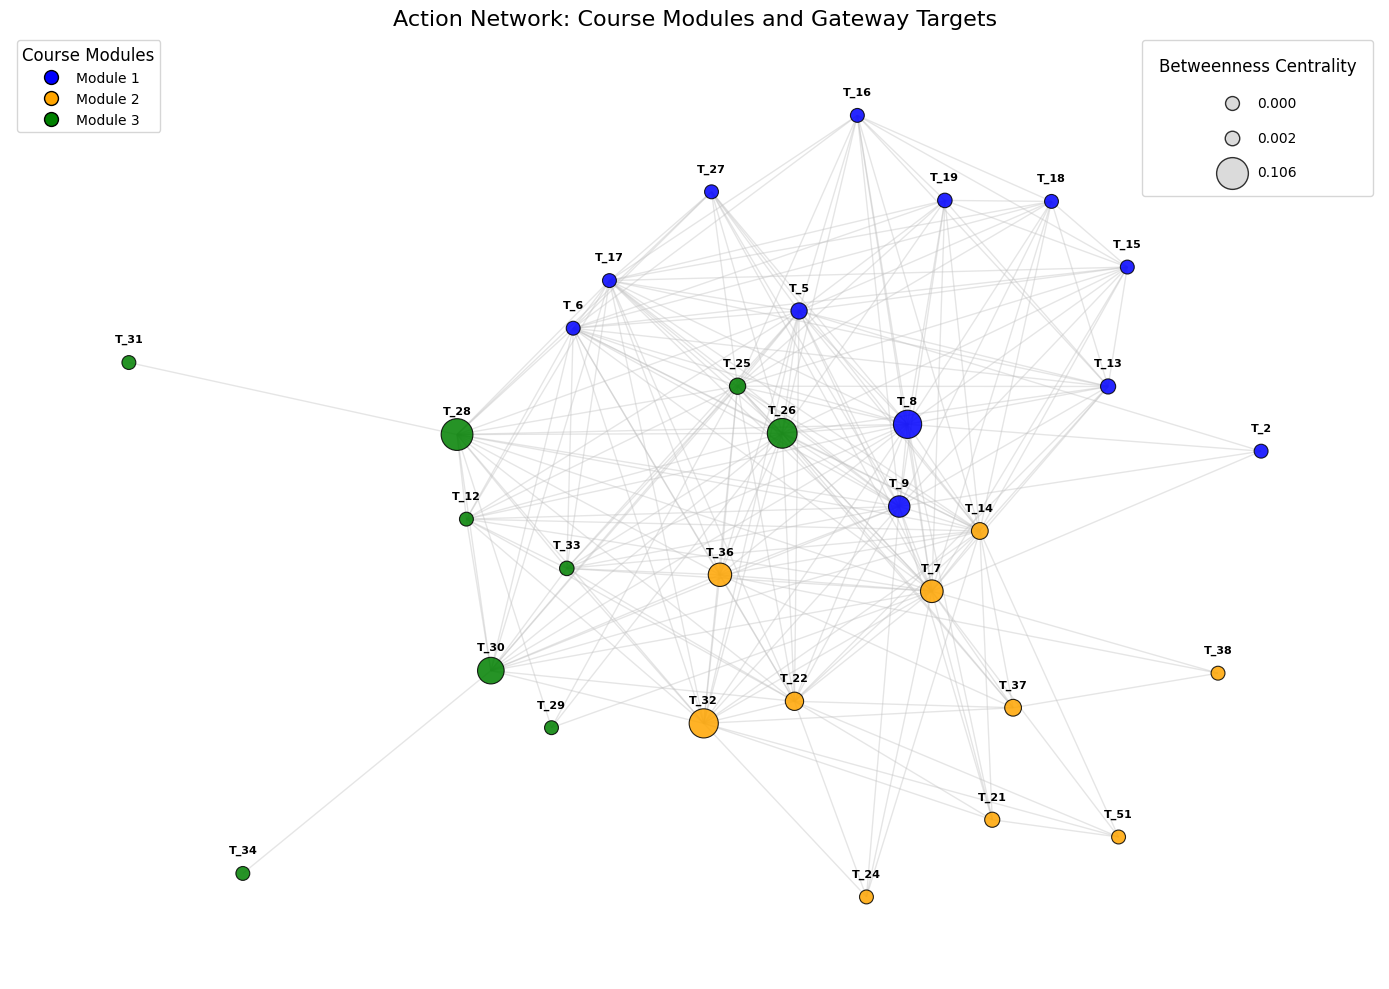

In [6]:
# Defines a palette of categorical colors.
colors = ['blue', 'orange', 'green', 'red', 'purple']

# Maps community colors to nodes.
color_map = {}
for idx, comm in enumerate(communities_A):
    for node in comm:
        color_map[node] = colors[idx]

# Compiles an ordered list of nodes.
ordered_nodes_A = list(G_actions.nodes())

# Assigns colors based on the ordered node list.
node_colors_A = [color_map[node] for node in ordered_nodes_A]

# Sets scaling parameters for node sizes.
scale_factor = 4000
base_size = 100

# Scaled node sizes based on betweenness centrality.
node_sizes_A = [(betweenness_A[node] * scale_factor) + base_size for node in ordered_nodes_A]

# Sets up the visualization canvas.
plt.figure(figsize=(14, 10))
plt.axis('off')
plt.title('Action Network: Course Modules and Gateway Targets', fontsize=16)

# Generates the network layout.
pos_A = nx.kamada_kawai_layout(G_actions)

# Draw the network edges.
nx.draw_networkx_edges(G_actions, pos_A, alpha=0.4, edge_color='silver')

# Draw the network nodes.
nx.draw_networkx_nodes(G_actions, pos_A, nodelist=ordered_nodes_A, node_size=node_sizes_A, node_color=node_colors_A, alpha=0.85, edgecolors='black', linewidths=0.8)

# Calculate label positions to prevent visual overlap.
pos_labels_A = {k: (v[0], v[1] + 0.04) for k, v in pos_A.items()}

# Adds labels to the nodes.
nx.draw_networkx_labels(G_actions, pos_labels_A, font_size=8, font_weight='bold')

# Creates community legend.
community_handles = []
for idx, color in enumerate(colors[:len(communities_A)]):
    handle = mlines.Line2D([], [], color=color, marker='o', linestyle='None', markersize=10, markeredgecolor='black', label=f'Module {idx+1}')
    community_handles.append(handle)
legend_color = plt.legend(handles=community_handles, title="Course Modules", loc='upper left', frameon=True, fontsize=10, title_fontsize=12)
plt.gca().add_artist(legend_color)

# Extracts centrality values for the size legend.
b_values = list(betweenness_A.values())
min_b, max_b, mid_b = min(b_values), max(b_values), np.median(b_values)

# Calculates scaled sizes for the legend markers.
legend_sizes = [(min_b * scale_factor) + base_size, (mid_b * scale_factor) + base_size, (max_b * scale_factor) + base_size]
legend_labels = [f"{min_b:.3f}", f"{mid_b:.3f}", f"{max_b:.3f}"]

# Creates scatter points for the size legend.
size_handles = []
for size, label in zip(legend_sizes, legend_labels):
    handle = plt.scatter([], [], s=size, color='lightgray', edgecolors='black', alpha=0.8, label=label)
    size_handles.append(handle)

# Places the size legend on the canvas.
plt.legend(handles=size_handles, title="Betweenness Centrality", loc='upper right', frameon=True, fontsize=10, title_fontsize=12, labelspacing=1.5, borderpad=1.2)

# Displays the final plot.
plt.tight_layout()
plt.show()